# Implementation !

Since we can't train a transformer over text here, simply because it would require huge datasets and computation resources, let's try some easier case that tries to mimick what happens in text.
Let's suppose a vocabulary consists of only three words, or tokens : a quare, a circle, and a cross $ \Omega = \{ X, O, \Box \}$

Now we must naturally introduce some rules for this language, let them be the following : 
- we can rither repeate one token, in this sentence no other word must intrefere : Ex : "X X X X X X"
- we can either have doubling sequence, repeating only two tokens : Ex : " X O X O X O"
- and finally, a circular rotation of all three tokens : " X O sq X O sq X O sq "

In [47]:
# ── Imports ─────────────────────────────────────────────────────────────────
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import matplotlib.patches as mpatches


In [2]:
torch.manual_seed(42)
np.random.seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cpu


In [3]:
# ── Vocabulary ───────────────────────────────────────────────────────────────
# x=0  o=1  sq=2  <PAD>=3
VOCAB      = {"x": 0, "o": 1, "sq": 2, "<PAD>": 3}
VOCAB_SIZE = len(VOCAB)
IDX2TOK    = {v: k for k, v in VOCAB.items()}
X, O, SQ   = 0, 1, 2

In [4]:
# ── Pattern generators ───────────────────────────────────────────────────────
def pattern_repeat(token, length=12):
    """x x x x x x"""
    return [token] * length

def pattern_cycle3(length=12):
    """x o sq x o sq ..."""
    base = [X, O, SQ]
    return (base * (length // 3 + 1))[:length]

def pattern_alternate1(length=12):
    """x o x o x o ..."""
    base = [X, O]
    return (base * (length // 2 + 1))[:length]

def pattern_alternate2(length=12):
    """x o x o x o ..."""
    base = [X, SQ]
    return (base * (length // 2 + 1))[:length]


PATTERNS = [
    lambda: pattern_repeat(X),
    lambda: pattern_repeat(O),
    lambda: pattern_repeat(SQ),
    pattern_cycle3,
    pattern_alternate1,
    pattern_alternate2,
]


In [5]:
# ── Dataset ──────────────────────────────────────────────────────────────────
class SequenceDataset(Dataset):
    def __init__(self, n_samples=8000, seq_len=12):
        self.seq_len = seq_len
        self.data    = []
        for _ in range(n_samples):
            fn  = PATTERNS[np.random.randint(len(PATTERNS))]
            seq = fn()
            # input = seq[:-1], target = seq[1:]  (autoregressive)
            self.data.append((
                torch.tensor(seq[:-1], dtype=torch.long),
                torch.tensor(seq[1:],  dtype=torch.long),
            ))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

In [6]:
dataset    = SequenceDataset(n_samples=8000, seq_len=12)
loader     = DataLoader(dataset, batch_size=128, shuffle=True)

In [7]:
# ── Transformer ──────────────────────────────────────────────────────────────
class TinyTransformer(nn.Module):
    """
    Small causal transformer for sequence modelling.

    Args:
        vocab_size  (int): Number of tokens.
        embed_dim   (int): Embedding dimensionality.
        n_heads     (int): Number of attention heads.
        n_layers    (int): Number of transformer blocks.
        seq_len     (int): Maximum sequence length.
        dropout     (float): Dropout probability.
    """
    def __init__(
        self,
        vocab_size: int = VOCAB_SIZE,
        embed_dim:  int = 32,
        n_heads:    int = 2,
        n_layers:   int = 2,
        seq_len:    int = 11,
        dropout:    float = 0.1,
    ):
        super().__init__()
        self.embed_dim = embed_dim
        self.seq_len   = seq_len

        # ── Token + positional embeddings ────────────────────────────────────
        self.token_emb = nn.Embedding(vocab_size, embed_dim)
        self.pos_emb   = nn.Embedding(seq_len,    embed_dim)

        # ── Transformer encoder layers (causal mask applied at forward) ──────
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=n_heads,
            dim_feedforward=64, dropout=dropout,
            batch_first=True,
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)

        # ── Output projection ────────────────────────────────────────────────
        self.head = nn.Linear(embed_dim, vocab_size)

    def _causal_mask(self, size: int) -> torch.Tensor:
        """Upper-triangular mask to prevent attending to future tokens."""
        return torch.triu(torch.ones(size, size, device=device), diagonal=1).bool()

    def forward(self, x: torch.Tensor):
        B, T    = x.shape
        pos     = torch.arange(T, device=device).unsqueeze(0)           # (1, T)
        emb     = self.token_emb(x) + self.pos_emb(pos)                 # (B, T, D)
        mask    = self._causal_mask(T)
        out     = self.transformer(emb, mask=mask)                      # (B, T, D)
        logits  = self.head(out)                                        # (B, T, V)
        return logits, out   # return hidden states for embedding analysis

    def get_contextual_embeddings(self, x: torch.Tensor):
        """Return hidden states (contextual embeddings) without logits."""
        _, hidden = self.forward(x)
        return hidden

In [9]:
def train(model, loader, epochs=30, lr=3e-3, ckpt_dir="checkpoints"):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history   = []
    os.makedirs(ckpt_dir, exist_ok=True)          # ← create folder once

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0

        for x, y in loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            logits, _ = model(x)
            loss = F.cross_entropy(
                logits.reshape(-1, VOCAB_SIZE),
                y.reshape(-1),
            )
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg = total_loss / len(loader)
        history.append(avg)

        if (epoch + 1) % 5 == 0:
            print(f"Epoch {epoch+1:3d}/{epochs} | Loss: {avg:.4f}")

            # ── Save checkpoint every 5 epochs ──────────────────────────────
            ckpt_path = os.path.join(ckpt_dir, f"ckpt_epoch{epoch+1}.pt")
            torch.save(
                {
                    "epoch":           epoch + 1,
                    "model_state":     model.state_dict(),
                    "optimizer_state": optimizer.state_dict(),
                    "loss":            avg,
                },
                ckpt_path,
            )
            print(f"  ✔ Checkpoint saved → {ckpt_path}")

    return history

In [10]:
# ── Data ─────────────────────────────────────────────────────────────────
dataset    = SequenceDataset(n_samples=8000, seq_len=12)
loader     = DataLoader(dataset, batch_size=128, shuffle=True)

# ── Model ────────────────────────────────────────────────────────────────
model = TinyTransformer(
    vocab_size=VOCAB_SIZE,
    embed_dim=32,
    n_heads=2,
    n_layers=2,
    seq_len=11,
).to(device)
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")



Parameters: 17,700


In [14]:
# ── Train ────────────────────────────────────────────────────────────────
history = train(model, loader, epochs=100, lr=3e-3)

Epoch   5/100 | Loss: 0.0850
  ✔ Checkpoint saved → checkpoints\ckpt_epoch5.pt
Epoch  10/100 | Loss: 0.0850
  ✔ Checkpoint saved → checkpoints\ckpt_epoch10.pt
Epoch  15/100 | Loss: 0.0860
  ✔ Checkpoint saved → checkpoints\ckpt_epoch15.pt
Epoch  20/100 | Loss: 0.0846
  ✔ Checkpoint saved → checkpoints\ckpt_epoch20.pt
Epoch  25/100 | Loss: 0.0847
  ✔ Checkpoint saved → checkpoints\ckpt_epoch25.pt
Epoch  30/100 | Loss: 0.0847
  ✔ Checkpoint saved → checkpoints\ckpt_epoch30.pt
Epoch  35/100 | Loss: 0.0845
  ✔ Checkpoint saved → checkpoints\ckpt_epoch35.pt
Epoch  40/100 | Loss: 0.0846
  ✔ Checkpoint saved → checkpoints\ckpt_epoch40.pt
Epoch  45/100 | Loss: 0.0848
  ✔ Checkpoint saved → checkpoints\ckpt_epoch45.pt
Epoch  50/100 | Loss: 0.0849
  ✔ Checkpoint saved → checkpoints\ckpt_epoch50.pt
Epoch  55/100 | Loss: 0.0847
  ✔ Checkpoint saved → checkpoints\ckpt_epoch55.pt
Epoch  60/100 | Loss: 0.0846
  ✔ Checkpoint saved → checkpoints\ckpt_epoch60.pt
Epoch  65/100 | Loss: 0.0854
  ✔ Checkpoi

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=3e-1)

# grab one batch and overfit it
x_single, y_single = next(iter(loader))
x_single, y_single = x_single.to(device), y_single.to(device)

for epoch in range(1000):
    model.train()
    optimizer.zero_grad()
    logits, _ = model(x_single)
    loss = F.cross_entropy(logits.reshape(-1, VOCAB_SIZE),
                           y_single.reshape(-1))
    loss.backward()
    optimizer.step()
    if (epoch+1) % 50 == 0:
        print(f"Epoch {epoch+1} | Loss: {loss.item():.5f}")

Epoch 50 | Loss: 0.94352
Epoch 100 | Loss: 0.88064
Epoch 150 | Loss: 0.88208
Epoch 200 | Loss: 0.77449
Epoch 250 | Loss: 0.68493
Epoch 300 | Loss: 0.74385
Epoch 350 | Loss: 0.74577
Epoch 400 | Loss: 0.74115
Epoch 450 | Loss: 0.65580
Epoch 500 | Loss: 0.69562
Epoch 550 | Loss: 0.63294
Epoch 600 | Loss: 0.61333
Epoch 650 | Loss: 0.70952
Epoch 700 | Loss: 0.60374
Epoch 750 | Loss: 0.61162
Epoch 800 | Loss: 0.59726
Epoch 850 | Loss: 0.57838
Epoch 900 | Loss: 0.55841
Epoch 950 | Loss: 0.56233
Epoch 1000 | Loss: 0.58615


In [54]:
optimizer = torch.optim.Adam(model.parameters(), lr=3e-2)

for epoch in range(1000):
    model.train()
    optimizer.zero_grad()
    logits, _ = model(x_single)
    loss = F.cross_entropy(logits.reshape(-1, VOCAB_SIZE),
                           y_single.reshape(-1))
    loss.backward()
    optimizer.step()
    if (epoch+1) % 50 == 0:
        print(f"Epoch {epoch+1} | Loss: {loss.item():.5f}")

Epoch 50 | Loss: 0.55685
Epoch 100 | Loss: 0.53460
Epoch 150 | Loss: 0.53089
Epoch 200 | Loss: 0.54163
Epoch 250 | Loss: 0.53081
Epoch 300 | Loss: 0.52889
Epoch 350 | Loss: 0.52014
Epoch 400 | Loss: 0.52917
Epoch 450 | Loss: 0.52277
Epoch 500 | Loss: 0.54022
Epoch 550 | Loss: 0.54902
Epoch 600 | Loss: 0.58388
Epoch 650 | Loss: 0.55817
Epoch 700 | Loss: 0.56127
Epoch 750 | Loss: 0.55522
Epoch 800 | Loss: 0.53590
Epoch 850 | Loss: 0.55184
Epoch 900 | Loss: 0.53001
Epoch 950 | Loss: 0.52043
Epoch 1000 | Loss: 0.53627


In [20]:

print(model._causal_mask(10))

tensor([[False,  True,  True,  True,  True,  True,  True,  True,  True,  True],
        [False, False,  True,  True,  True,  True,  True,  True,  True,  True],
        [False, False, False,  True,  True,  True,  True,  True,  True,  True],
        [False, False, False, False,  True,  True,  True,  True,  True,  True],
        [False, False, False, False, False,  True,  True,  True,  True,  True],
        [False, False, False, False, False, False,  True,  True,  True,  True],
        [False, False, False, False, False, False, False,  True,  True,  True],
        [False, False, False, False, False, False, False, False,  True,  True],
        [False, False, False, False, False, False, False, False, False,  True],
        [False, False, False, False, False, False, False, False, False, False]])


In [21]:
for name, param in model.named_parameters():
    if param.grad is not None:
        print(f"{name:40s} grad_norm={param.grad.norm():.5f}")
    else:
        print(f"{name:40s} NO GRADIENT")

token_emb.weight                         grad_norm=0.00160
pos_emb.weight                           grad_norm=0.00161
transformer.layers.0.self_attn.in_proj_weight grad_norm=0.00013
transformer.layers.0.self_attn.in_proj_bias grad_norm=0.00002
transformer.layers.0.self_attn.out_proj.weight grad_norm=0.00011
transformer.layers.0.self_attn.out_proj.bias grad_norm=0.00165
transformer.layers.0.linear1.weight      grad_norm=0.00756
transformer.layers.0.linear1.bias        grad_norm=0.00110
transformer.layers.0.linear2.weight      grad_norm=0.00394
transformer.layers.0.linear2.bias        grad_norm=0.00168
transformer.layers.0.norm1.weight        grad_norm=0.00235
transformer.layers.0.norm1.bias          grad_norm=0.00252
transformer.layers.0.norm2.weight        grad_norm=0.00240
transformer.layers.0.norm2.bias          grad_norm=0.00261
transformer.layers.1.self_attn.in_proj_weight grad_norm=0.00049
transformer.layers.1.self_attn.in_proj_bias grad_norm=0.00008
transformer.layers.1.self_attn

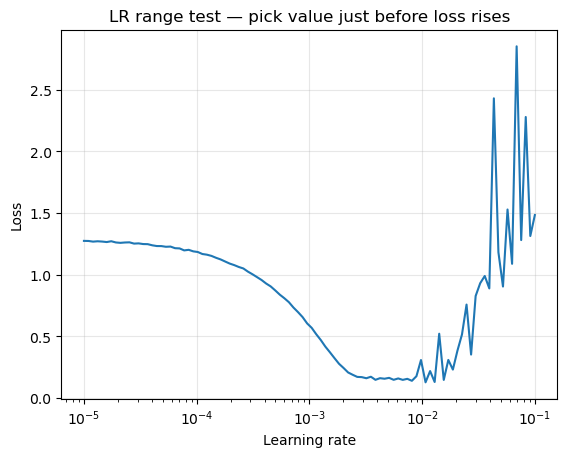

In [22]:
lrs    = np.logspace(-5, -1, 100)   # 1e-5 to 1e-1
losses = []

model_test = TinyTransformer().to(device)
x, y = next(iter(loader))
x, y = x.to(device), y.to(device)

for lr in lrs:
    opt = torch.optim.Adam(model_test.parameters(), lr=lr)
    opt.zero_grad()
    logits, _ = model_test(x)
    loss = F.cross_entropy(logits.reshape(-1, VOCAB_SIZE), y.reshape(-1))
    loss.backward()
    opt.step()
    losses.append(loss.item())

plt.plot(lrs, losses); plt.xscale("log")
plt.xlabel("Learning rate"); plt.ylabel("Loss")
plt.title("LR range test — pick value just before loss rises")
plt.grid(alpha=0.3); plt.show()

In [55]:

# ── Visualisation helpers ─────────────────────────────────────────────────────
COLORS  = {"x": "#E05A5A", "o": "#5A9BE0", "sq": "#5AC476"}
MARKERS = {"x": "X",       "o": "o",       "sq": "s"}

def plot_loss(history):
    plt.figure(figsize=(7, 3))
    plt.plot(history, linewidth=2, color="#5A9BE0")
    plt.xlabel("Epoch"); plt.ylabel("Cross-entropy loss")
    plt.title("Training loss"); plt.grid(alpha=0.3)
    plt.tight_layout(); plt.show()


def plot_static_embeddings(model):
    """Plot the raw token embedding table — before context."""
    W   = model.token_emb.weight.detach().cpu().numpy()[:3]   # x, o, sq
    pca = PCA(n_components=2).fit_transform(W)

    fig, ax = plt.subplots(figsize=(5, 5))
    for i, tok in enumerate(["x", "o", "sq"]):
        ax.scatter(*pca[i], s=300, color=COLORS[tok],
                   marker=MARKERS[tok], zorder=3, label=tok)
        ax.annotate(tok, pca[i], textcoords="offset points",
                    xytext=(8, 4), fontsize=12)
    ax.set_title("Static token embeddings (before attention)")
    ax.legend(); ax.grid(alpha=0.2)
    plt.tight_layout(); plt.show()


def plot_contextual_embeddings(model):
    """
    Extract the contextual embedding of token X across all pattern contexts.
    Same input token → different output vector depending on pattern.
    This is the 'avocado moment'.
    """
    model.eval()

    # One representative sequence per pattern (length 11 = seq_len)
    test_seqs = {
        "repeat-x":      pattern_repeat(X)[:-1],
        "cycle-3":       pattern_cycle3()[:-1],
    }

    all_vecs, all_labels, all_tokens = [], [], []

    with torch.no_grad():
        for pattern_name, seq in test_seqs.items():
            t      = torch.tensor(seq, dtype=torch.long).unsqueeze(0).to(device)
            hidden = model.get_contextual_embeddings(t)[0]   # (T, D)

            for pos, tok_id in enumerate(seq):
                tok_name = IDX2TOK[tok_id]
                all_vecs.append(hidden[pos].cpu().numpy())
                all_labels.append(pattern_name)
                all_tokens.append(tok_name)

    vecs = np.array(all_vecs)
    pca  = PCA(n_components=2).fit_transform(vecs)

    # ── Plot: colour = pattern, shape = token ────────────────────────────────
    pattern_colors = {
        "repeat-x":      "#E05A5A",
        "cycle-3":       "#5A9BE0",
        "alternating":   "#5AC476",
        "reverse-cycle": "#E0A85A",
    }

    fig, ax = plt.subplots(figsize=(8, 6))
    for i, (label, tok) in enumerate(zip(all_labels, all_tokens)):
        ax.scatter(
            pca[i, 0], pca[i, 1],
            color=pattern_colors[label],
            marker=MARKERS[tok],
            s=120, alpha=0.8,
        )

    # Legend: patterns
    pat_patches = [
        mpatches.Patch(color=c, label=p)
        for p, c in pattern_colors.items()
    ]
    # Legend: tokens
    tok_handles = [
        plt.scatter([], [], marker=MARKERS[t], color="gray", s=80, label=t)
        for t in ["x", "o", "sq"]
    ]
    ax.legend(handles=pat_patches + tok_handles,
              loc="upper right", fontsize=9, framealpha=0.8)
    ax.set_title("Contextual embeddings — same token, different context\n"
                 "(colour = pattern, shape = token)")
    ax.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()


def plot_attention_maps(model):
    """
    Plot attention weights for each pattern.
    Uses the first head of the first layer.
    """
    model.eval()

    test_seqs = {
        "repeat-x":      pattern_repeat(X)[:-1],
        "cycle-3":       pattern_cycle3()[:-1]
    }

    # Register a hook on the first attention layer
    attention_weights = {}

    def hook_fn(module, input, output):
        # output[1] = attention weights when need_weights=True
        if isinstance(output, tuple) and output[1] is not None:
            attention_weights["attn"] = output[1].detach().cpu()

    # Hook into the self-attention of the first encoder layer
    handle = model.transformer.layers[0].self_attn.register_forward_hook(hook_fn)

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))

    with torch.no_grad():
        for ax, (name, seq) in zip(axes, test_seqs.items()):
            t = torch.tensor(seq, dtype=torch.long).unsqueeze(0).to(device)

            # need_weights must be True — patch the layer temporarily
            model.transformer.layers[0].self_attn.need_weights = True
            model(t)

            if "attn" in attention_weights:
                # shape: (B, heads, T, T) or (B, T, T) depending on version
                w = attention_weights["attn"]
                if w.dim() == 4:
                    w = w[0, 0]   # first batch, first head
                else:
                    w = w[0]

                tok_labels = [IDX2TOK[i] for i in seq]
                im = ax.imshow(w.numpy(), cmap="Blues", vmin=0, vmax=1)
                ax.set_xticks(range(len(seq))); ax.set_xticklabels(tok_labels, fontsize=8)
                ax.set_yticks(range(len(seq))); ax.set_yticklabels(tok_labels, fontsize=8)
                ax.set_title(name, fontsize=10)
                plt.colorbar(im, ax=ax, fraction=0.046)
            attention_weights.clear()

    handle.remove()
    plt.suptitle("Attention maps — head 0, layer 0", fontsize=12, y=1.02)
    plt.tight_layout()
    plt.show()


# ── Generation ────────────────────────────────────────────────────────────────
def generate(model, prompt: list, n_new: int = 6) -> list:
    """Autoregressively generate n_new tokens given a prompt."""
    model.eval()
    seq = prompt[:]
    with torch.no_grad():
        for _ in range(n_new):
            t      = torch.tensor(seq[-model.seq_len:],
                                  dtype=torch.long).unsqueeze(0).to(device)
            logits, _ = model(t)
            next_tok  = logits[0, -1].argmax().item()
            seq.append(next_tok)
    return seq


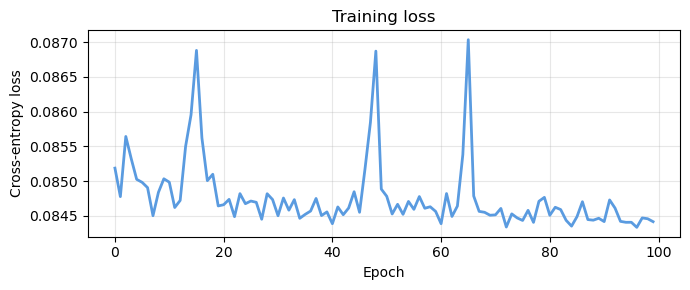

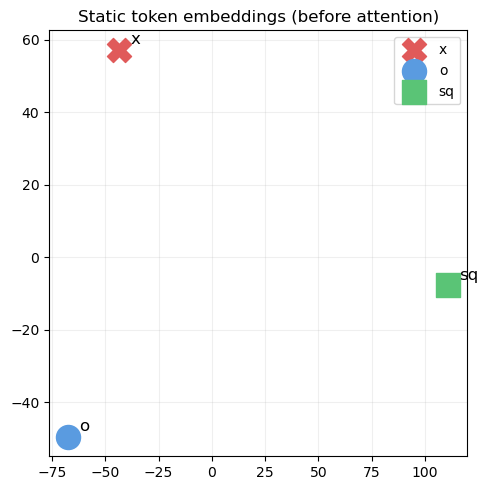

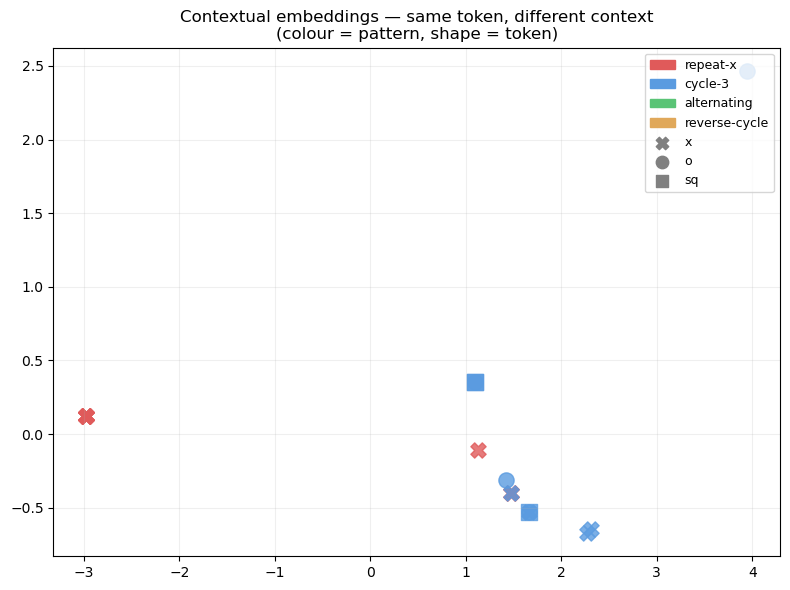

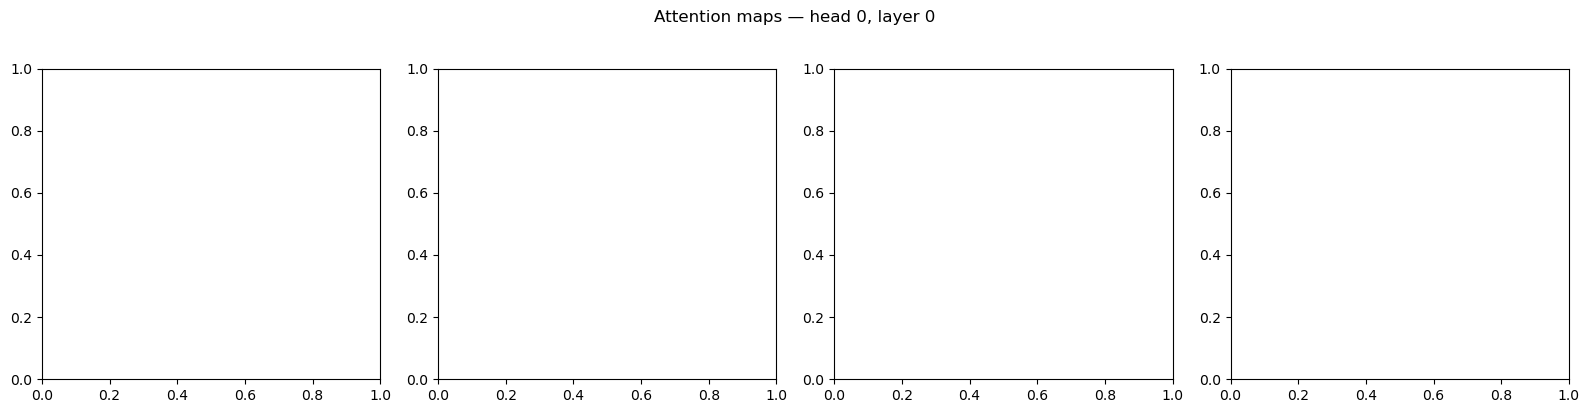

In [56]:
plot_loss(history)
plot_static_embeddings(model)
plot_contextual_embeddings(model)
plot_attention_maps(model)

In [45]:
# ── Generation demo ──────────────────────────────────────────────────────
print("\n── Generation demo ──────────────────────────────────────")
prompts = {
    "repeat-x  prompt [x,x,x]":         [X, X, X],
    "cycle-3   prompt [x,o,sq,x]":       [X, O, SQ, X, O, SQ, X],
    "alternate prompt [x,o,x,o]":        [X, O, X, O, X, O],
    "rev-cycle prompt [sq,o,x,sq]":      [SQ, O, X, SQ, O, X],
}
for desc, prompt in prompts.items():
    result = generate(model, prompt, n_new=6)
    readable = " ".join(IDX2TOK[t] for t in result)
    print(f"{desc:45s} → {readable}")


── Generation demo ──────────────────────────────────────
repeat-x  prompt [x,x,x]                      → x x x x x x x x x
cycle-3   prompt [x,o,sq,x]                   → x o sq x o sq x o sq sq sq sq sq
alternate prompt [x,o,x,o]                    → x o x o x o o o o o o o
rev-cycle prompt [sq,o,x,sq]                  → sq o x sq o x sq sq sq sq sq sq
